## Introduction 

The goal is to predict whether an online visitor will eventually make a purchase based on their browsing behavior (e.g., did they put items in the basket, did they sign in, etc.). This allows e-commerce platforms to target "window shoppers" with specific discounts to convert them into buyers.

## Importing Libraries & Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Styling
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")

In [ ]:
# importing the dataset 
df = pd.read_csv("User_Behaviour.csv")
print("\nProportions:\n", df['ordered'].value_counts(normalize=True))
print("\nTotal Rows:", len(df))


Proportions:
 ordered
0    0.958074
1    0.041926
Name: proportion, dtype: float64

Total Rows: 455401


## Data Preparation

- Data Audit & Structural Analysis 
- Checking and Handling the missing values

In [3]:
df.head(5)

,UserID,basket_icon_click,basket_add_list,basket_add_detail,sort_by,image_picker,account_page_click,promo_banner_click,detail_wishlist_add,list_size_dropdown,...,saw_sizecharts,saw_delivery,saw_account_upgrade,saw_homepage,device_mobile,device_computer,device_tablet,returning_user,loc_uk,ordered
0,a720-6b732349-a720-4862-bd21-644732,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,a0c0-6b73247c-a0c0-4bd9-8baa-797356,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,86a8-6b735c67-86a8-407b-ba24-333055,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,1,0
3,6a3d-6b736346-6a3d-4085-934b-396834,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,1,0
4,b74a-6b737717-b74a-45c3-8c6a-421140,0,1,0,1,0,0,0,0,1,...,0,0,0,1,0,0,1,0,1,1


In [4]:
print("\n--- Statistical Overview ---")
df.describe()


--- Statistical Overview ---


,basket_icon_click,basket_add_list,basket_add_detail,sort_by,image_picker,account_page_click,promo_banner_click,detail_wishlist_add,list_size_dropdown,closed_minibasket_click,...,saw_sizecharts,saw_delivery,saw_account_upgrade,saw_homepage,device_mobile,device_computer,device_tablet,returning_user,loc_uk,ordered
count,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,...,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000
mean,0.099150,0.074521,0.112916,0.036849,0.026735,0.003570,0.016208,0.003511,0.230362,0.017277,...,0.000389,0.005542,0.001096,0.290024,0.680706,0.194220,0.128364,0.534915,0.933224,0.041926
std,0.298864,0.262617,0.316490,0.188391,0.161307,0.059647,0.126274,0.059151,0.421065,0.130302,...,0.019711,0.074241,0.033084,0.453773,0.466204,0.395599,0.334495,0.498780,0.249634,0.200420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
print("--- Columns and Data Types ---") 
df.info()

--- Columns and Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455401 entries, 0 to 455400
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   UserID                   455401 non-null  object
 1   basket_icon_click        455401 non-null  int64 
 2   basket_add_list          455401 non-null  int64 
 3   basket_add_detail        455401 non-null  int64 
 4   sort_by                  455401 non-null  int64 
 5   image_picker             455401 non-null  int64 
 6   account_page_click       455401 non-null  int64 
 7   promo_banner_click       455401 non-null  int64 
 8   detail_wishlist_add      455401 non-null  int64 
 9   list_size_dropdown       455401 non-null  int64 
 10  closed_minibasket_click  455401 non-null  int64 
 11  checked_delivery_detail  455401 non-null  int64 
 12  checked_returns_detail   455401 non-null  int64 
 13  sign_in                  455401 non-null  i

In [6]:
print("\n--- Missing Values Count ---")
print(df.isnull().sum())


--- Missing Values Count ---
UserID                     0
basket_icon_click          0
basket_add_list            0
basket_add_detail          0
sort_by                    0
image_picker               0
account_page_click         0
promo_banner_click         0
detail_wishlist_add        0
list_size_dropdown         0
closed_minibasket_click    0
checked_delivery_detail    0
checked_returns_detail     0
sign_in                    0
saw_checkout               0
saw_sizecharts             0
saw_delivery               0
saw_account_upgrade        0
saw_homepage               0
device_mobile              0
device_computer            0
device_tablet              0
returning_user             0
loc_uk                     0
ordered                    0
dtype: int64


In [7]:
print("\n--- Target Variable Count (Ordered) ---")
print(df['ordered'].value_counts())


--- Target Variable Count (Ordered) ---
ordered
0    436308
1     19093
Name: count, dtype: int64


The ratio of ordered and not ordered is not good for model traning, will have to perform data modeling so model can be trained properly

## Exploratory Data Analysis 

C:\Users\Harshad koli\AppData\Local\Temp\ipykernel_38088\1928313275.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='ordered', data=df, ax=ax[0], palette='viridis')


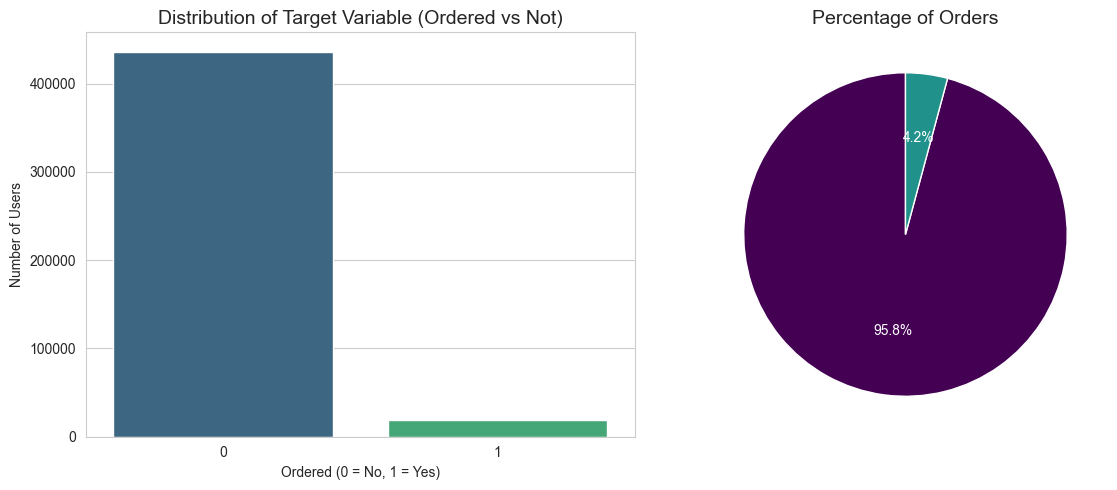

In [8]:
# Target Variable Distribution - since the taget variable count was disproportionate 

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# 1. Bar Chart (Count)
sns.countplot(x='ordered', data=df, ax=ax[0], palette='viridis')
ax[0].set_title('Distribution of Target Variable (Ordered vs Not)', fontsize=14)
ax[0].set_xlabel('Ordered (0 = No, 1 = Yes)')
ax[0].set_ylabel('Number of Users')

# 2. Pie Chart (Percentage)
# We calculate the percentages first
order_counts = df['ordered'].value_counts()
ax[1].pie(order_counts, labels=['Not Ordered', 'Ordered'], 
        autopct='%1.1f%%', startangle=90, colors=['#440154', '#21918c'], 
        explode=(0, 0), shadow=False, textprops={'color': 'white'})
ax[1].set_title('Percentage of Orders', fontsize=14)

plt.tight_layout()
plt.show()

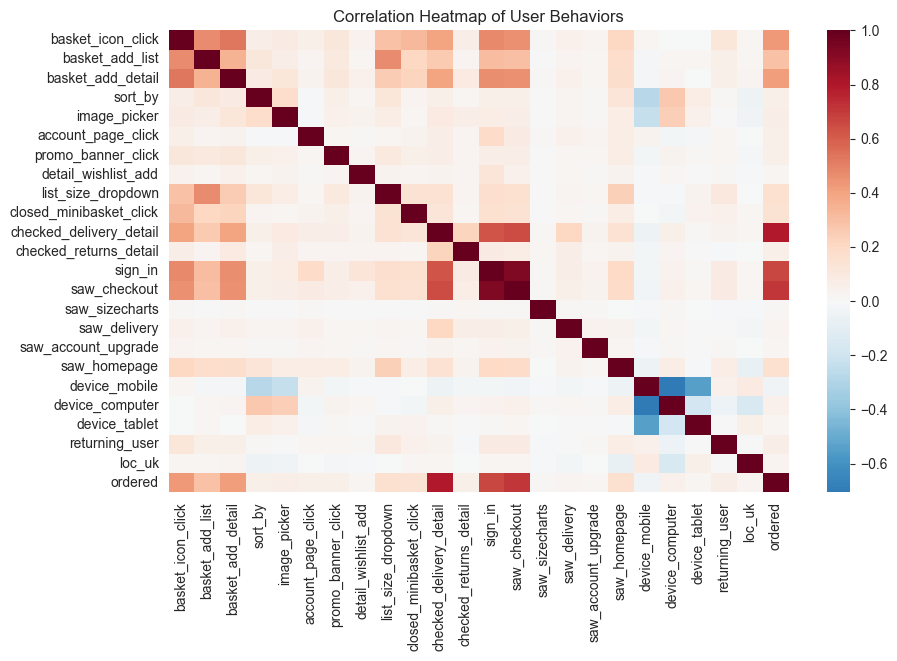


Top Correlations with 'ordered':
   checked_delivery_detail       : +0.799
   saw_checkout                  : +0.709
   sign_in                       : +0.666
   basket_icon_click             : +0.428
   basket_add_detail             : +0.414
   basket_add_list               : +0.288
   saw_homepage                  : +0.158
   list_size_dropdown            : +0.155
   closed_minibasket_click       : +0.140
   image_picker                  : +0.071


In [9]:
# Correlation Heatmap - To identify which user actions have the strongest mathematical relationship with a purchase.

plt.figure(figsize=(10, 6))
# We only use numeric columns for correlation
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap of User Behaviors')
plt.show()



# --- Top Correlations with Target ('ordered') ---
print("\nTop Correlations with 'ordered':")
# Sort by absolute value to see strongest relationships (positive or negative)
target_corr = corr_matrix['ordered'].drop('ordered').abs().sort_values(ascending=False)

for feat, val in target_corr.head(10).items():
    direction = '+' if corr_matrix.loc[feat, 'ordered'] > 0 else '-'
    print(f"   {feat:30s}: {direction}{val:.3f}")

C:\Users\Harshad koli\AppData\Local\Temp\ipykernel_38088\514162762.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='ordered', data=df, ax=axes[row, col_idx], palette='viridis')
C:\Users\Harshad koli\AppData\Local\Temp\ipykernel_38088\514162762.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='ordered', data=df, ax=axes[row, col_idx], palette='viridis')
C:\Users\Harshad koli\AppData\Local\Temp\ipykernel_38088\514162762.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='ordered', data=df, ax=axes[row, col_id

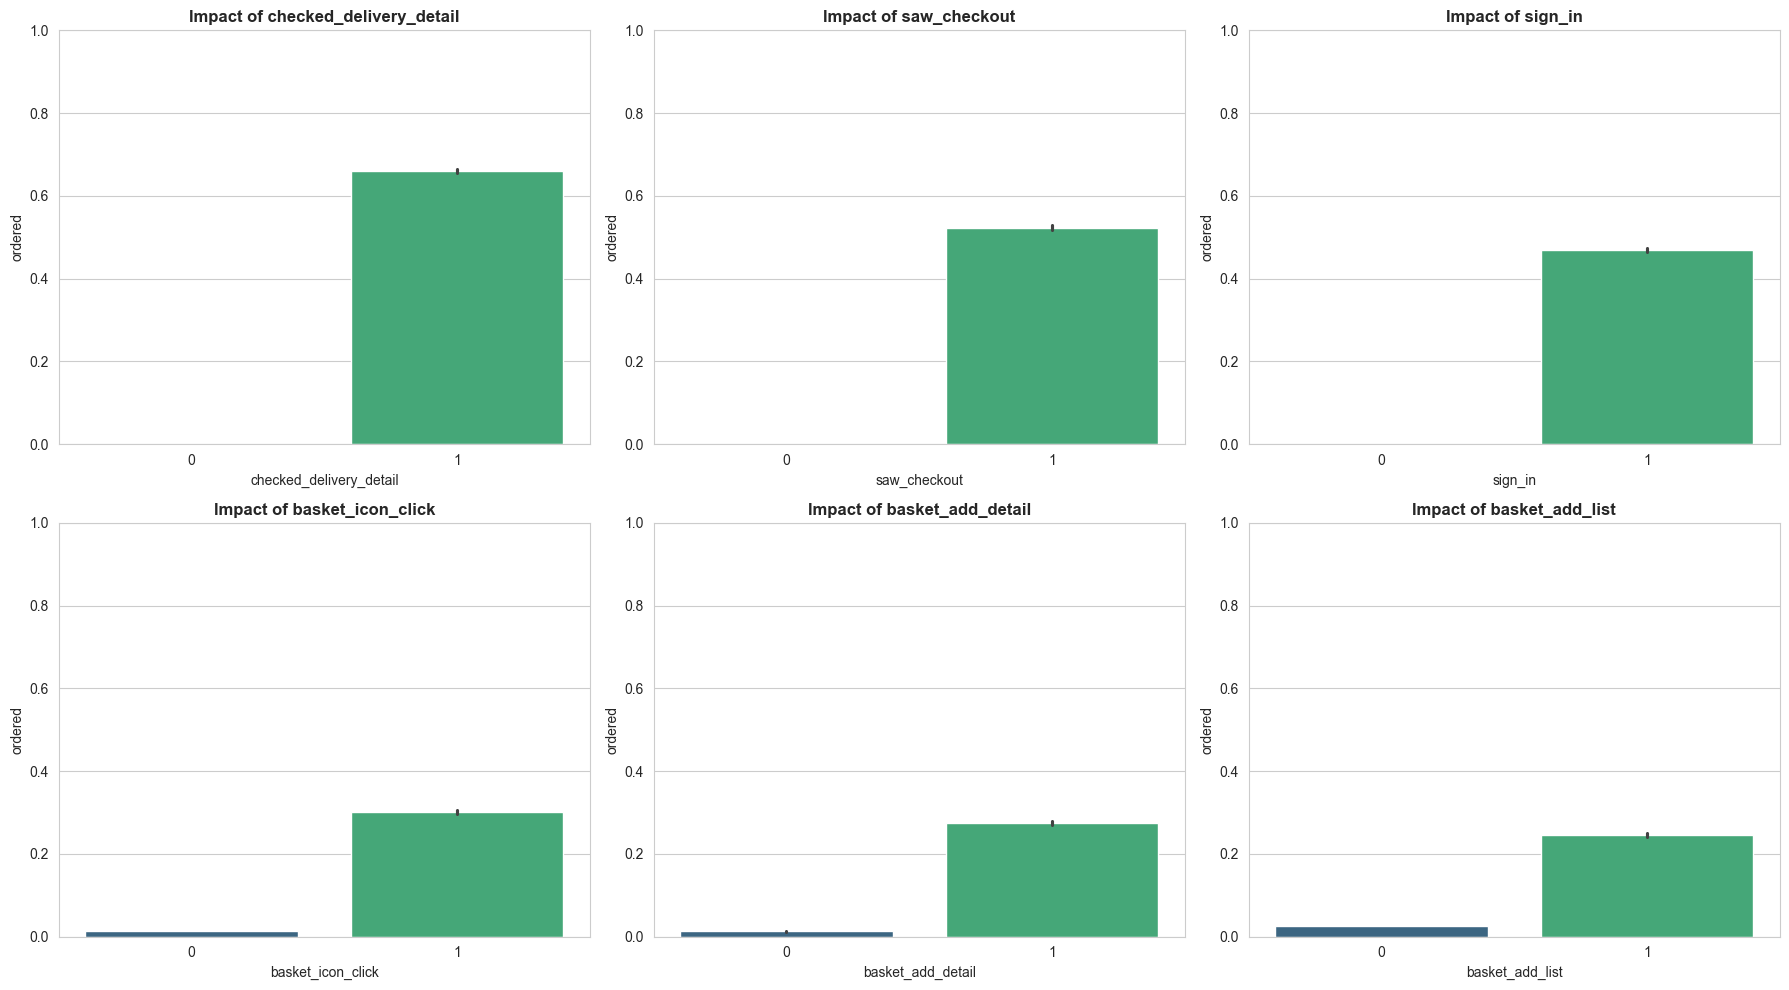

In [10]:
# Creating a subplot for the Top 6 Predictors
top_6 = ['checked_delivery_detail', 'saw_checkout', 'sign_in', 'basket_icon_click', 'basket_add_detail', 'basket_add_list']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(top_6):
    row = i // 3
    col_idx = i % 3
    sns.barplot(x=col, y='ordered', data=df, ax=axes[row, col_idx], palette='viridis')
    axes[row, col_idx].set_title(f'Impact of {col}', fontweight='bold')
    axes[row, col_idx].set_ylim(0, 1) # Keep scale consistent to show the massive jump

plt.tight_layout()
plt.show()

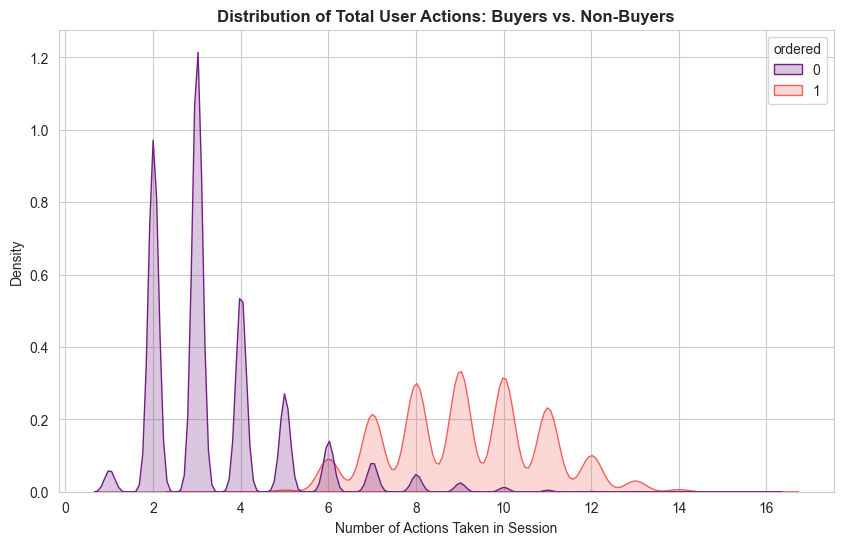

In [11]:
# Looking for other factors that might have a strong relationship with 'ordered' 

# 1. total actions (sum of all user actions) 

# Create a new temporary feature for visualization: Total Actions
# Summing all behavioral columns (excluding 'ordered' and 'User_ID')
behavior_cols = [col for col in df.columns if col not in ['ordered', 'UserID']]
df['total_actions'] = df[behavior_cols].sum(axis=1)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='total_actions', hue='ordered', fill=True, palette='magma', common_norm=False)
plt.title('Distribution of Total User Actions: Buyers vs. Non-Buyers', fontweight='bold')
plt.xlabel('Number of Actions Taken in Session')
plt.show()

<Figure size 600x400 with 0 Axes>

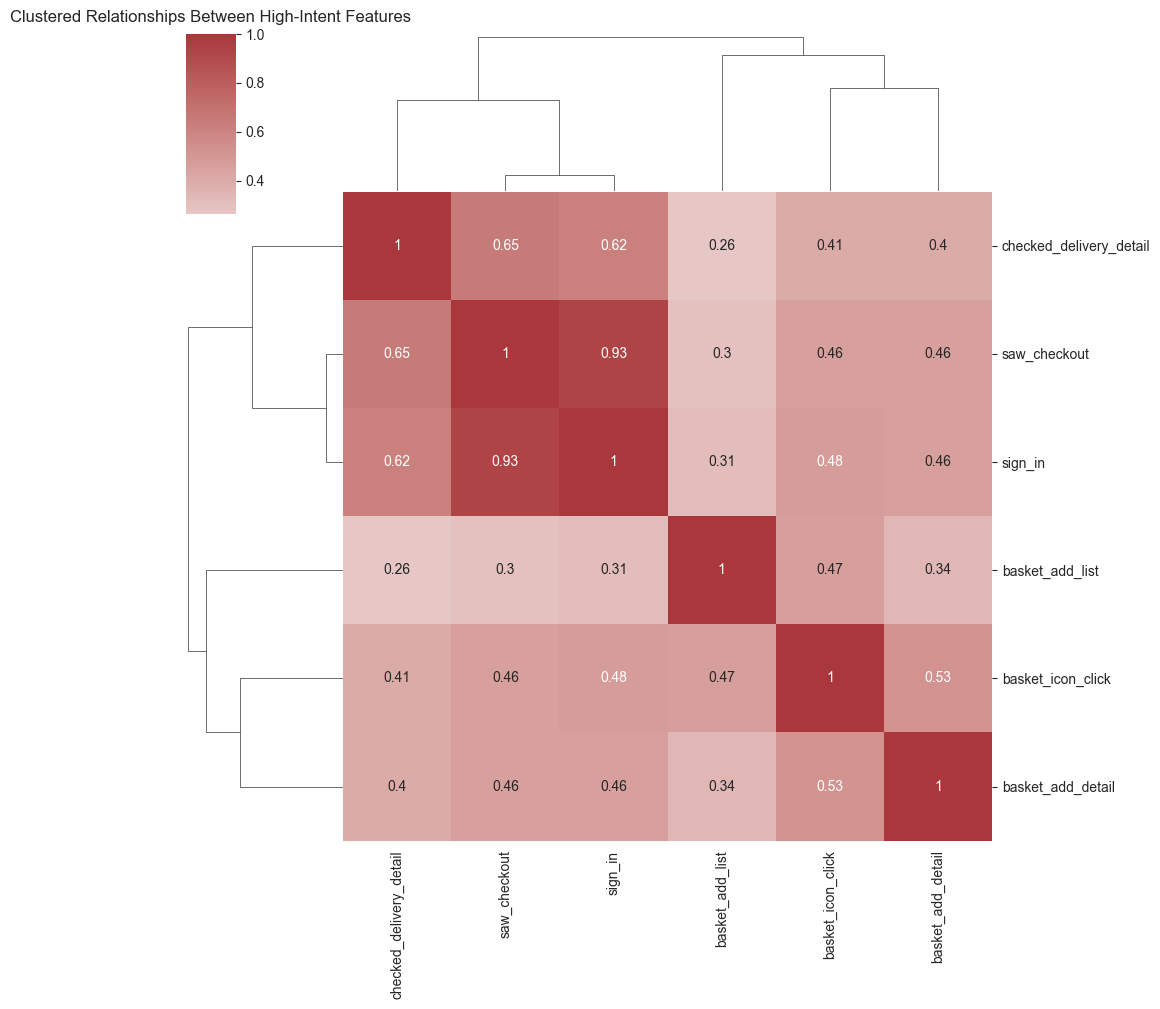

In [12]:
# 2. Feature Interaction Heatmap - To see if any of the top features interact with each other in a way that might influence purchasing behavior.

# Select the top 10 features from your previous correlation list
top_10_features = target_corr.head(6).index.tolist()
plt.figure(figsize=(6, 4))
sns.clustermap(df[top_10_features].corr(), annot=True, cmap='vlag', center=0)
plt.title('Clustered Relationships Between High-Intent Features', y=1.02)
plt.show()

C:\Users\Harshad koli\AppData\Local\Temp\ipykernel_38088\1180791616.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(['Desktop/Other', 'Mobile'])
C:\Users\Harshad koli\AppData\Local\Temp\ipykernel_38088\1180791616.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='device_mobile', y='ordered', data=df, ax=ax1, palette='rocket', ci=None)
C:\Users\Harshad koli\AppData\Local\Temp\ipykernel_38088\1180791616.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='device_mobile', y='ordered', data=df, ax=ax1, palette='rocket', ci=None)
C:\Users\Harshad koli\AppData\Local\Temp\ipykernel_38088\1180791616.py:31: UserWarning: set_ticklabels() should only be used with a fixed nu

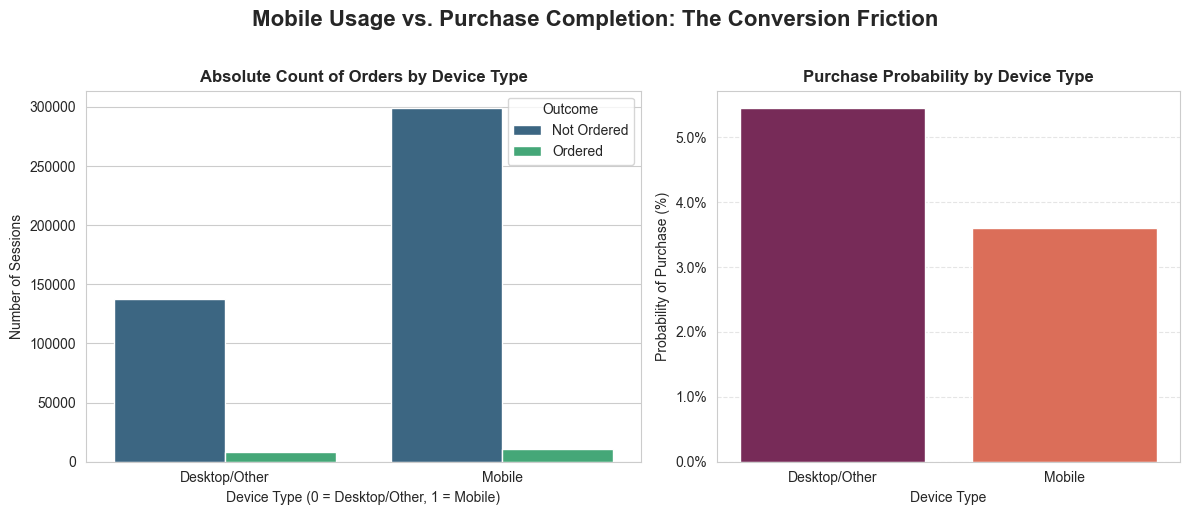

In [13]:
import matplotlib.gridspec as gridspec

# Setting up a professional segmented layout
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1]) 
plt.suptitle('Mobile Usage vs. Purchase Completion: The Conversion Friction', fontsize=16, fontweight='bold', y=1.02)

# --- Subplot 1: Absolute Counts (Bar Chart) ---
ax0 = plt.subplot(gs[0])
# We compare the count of 0 (No Purchase) vs 1 (Purchase) across Mobile (1) vs Desktop (0)
sns.countplot(x='device_mobile', hue='ordered', data=df, ax=ax0, palette='viridis')
ax0.set_title('Absolute Count of Orders by Device Type', fontsize=12, fontweight='bold')
ax0.set_xlabel('Device Type (0 = Desktop/Other, 1 = Mobile)')
ax0.set_ylabel('Number of Sessions')
# Custom labels for clarity
ax0.set_xticklabels(['Desktop/Other', 'Mobile'])
ax0.legend(['Not Ordered', 'Ordered'], title='Outcome', frameon=True)


# --- Subplot 2: Purchase Probability (Bar Chart showing MEAN) ---
ax1 = plt.subplot(gs[1])
# Seaborn automatically calculates the MEAN (probability) when Y is a binary variable (0/1)
sns.barplot(x='device_mobile', y='ordered', data=df, ax=ax1, palette='rocket', ci=None)
ax1.set_title('Purchase Probability by Device Type', fontsize=12, fontweight='bold')
ax1.set_xlabel('Device Type')
ax1.set_ylabel('Probability of Purchase (%)')
# Converting y-axis to percentage
from matplotlib.ticker import PercentFormatter
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
# Custom labels
ax1.set_xticklabels(['Desktop/Other', 'Mobile'])
ax1.yaxis.grid(True, linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()

## Data Modeling

Feature engineering and Splitting the Dataset

In [16]:
# Dropping the ID column
df_model = df.drop(['UserID'], axis=1)
print("\nProportions:\n", df['ordered'].value_counts())
print("\nTotal Rows:", len(df))


Proportions:
 ordered
0    436308
1     19093
Name: count, dtype: int64

Total Rows: 455401


In [ ]:
# Leaky Features - These are features that are performed after purchase and guarantees a purchase, these features gives unfair advantage to predict if a purchase was made
leaky_cols = ['saw_checkout', 'checked_delivery_detail', 'sign_in', 'checked_returns_detail']

Handling the Class Imbalance

We split the dataset into test and train in 80/20 ratio while keeping the class imbalance of 90/10.
Then resample the train dataset from 90/10 class imbalance to 80/20

In [21]:
# 1. Splitting the imbalanced df_model 
X_org = df_model.drop('ordered', axis=1)
y_org = df_model['ordered']

# 2. Split into Train/Test (80/20) 
X_train_org, X_test, y_train_org, y_test = train_test_split(X_org, y_org, test_size=0.2, random_state=42, stratify=y_org)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_org)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_org.shape)
print("Test set shape:", X_test.shape)

Training set shape: (364320, 24)
Test set shape: (91081, 24)


In [ ]:
# for 1 lakh rows dataset

# 3. Now, only up-sample the TRAINING part
# (This keeps the test set 'pure' and unseen)
train_df = pd.concat([X_train_org, y_train_org], axis=1)
df_ordered = train_df[train_df['ordered'] == 1]
df_not_ordered = train_df[train_df['ordered'] == 0]

# Upsample training buyers to 20k, downsample training non-buyers to 80k
df_ordered_up = df_ordered.sample(n=16000, replace=True, random_state=42)
df_not_ordered_down = df_not_ordered.sample(n=64000, random_state=42)

train_balanced = pd.concat([df_ordered_up, df_not_ordered_down]).sample(frac=1)
X_train = train_balanced.drop('ordered', axis=1)
y_train = train_balanced['ordered']

# 4. Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Classification Modeling - 4 ML Models

In [ ]:
# Initialize and Train
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 2. Make Predictions on the "Pure" Test Set
y_pred_log = log_reg.predict(X_test_scaled)

# 3. Print Performance Metrics
print("--- Logistic Regression: Leakage-Free Results ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_log):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

In [22]:
results = {}

## 1. Logistic Regression Model

In [23]:
# Drop them from your balanced training and original test sets
X_train_clean = X_train.drop(columns=leaky_cols)
X_test_clean = X_test.drop(columns=leaky_cols)

# Re-Scale the CLEAN data
scaler_clean = StandardScaler()
X_train_clean_scaled = scaler_clean.fit_transform(X_train_clean)
X_test_clean_scaled = scaler_clean.transform(X_test_clean)

# Train a NEW model
log_reg_clean = LogisticRegression(max_iter=1000)
log_reg_clean.fit(X_train_clean_scaled, y_train)

# Predict and Evaluate
y_pred_clean = log_reg_clean.predict(X_test_clean_scaled)

print("--- CLEAN MODEL PERFORMANCE (No Leaky Features) ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_clean):.4f}")
print(classification_report(y_test, y_pred_clean))

# Apend the results to the dictionary for later comparison
y_prob_log = log_reg_clean.predict_proba(X_test_clean_scaled)[:, 1]

results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_clean),
    'Precision': precision_score(y_test, y_pred_clean),
    'Recall': recall_score(y_test, y_pred_clean),
    'F1-Score': f1_score(y_test, y_pred_clean),
    'ROC-AUC': roc_auc_score(y_test, y_prob_log),
    'y_pred': y_pred_clean,
    'y_prob': y_prob_log
}

--- CLEAN MODEL PERFORMANCE (No Leaky Features) ---
Accuracy Score: 0.9348
              precision    recall  f1-score   support

           0       0.98      0.95      0.97     87262
           1       0.35      0.66      0.46      3819

    accuracy                           0.93     91081
   macro avg       0.67      0.80      0.71     91081
weighted avg       0.96      0.93      0.94     91081



## 2. KNN Model

In [24]:
# 1. Initialize the KNN Model
# n_neighbors=5 is the standard starting point
knn_model = KNeighborsClassifier(n_neighbors=5)

# 2. Train the model 
# (Note: KNN is 'lazy', it mostly just stores the data here)
knn_model.fit(X_train_clean_scaled, y_train)

# 3. Predict and Evaluate
y_pred_knn = knn_model.predict(X_test_clean_scaled)

print("--- K-Nearest Neighbors (KNN) Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# Append KNN results to the dictionary

# KNN uses predict_proba for ROC-AUC
y_prob_knn = knn_model.predict_proba(X_test_clean_scaled)[:, 1]

results['KNN'] = {
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn),
    'Recall': recall_score(y_test, y_pred_knn),
    'F1-Score': f1_score(y_test, y_pred_knn),
    'ROC-AUC': roc_auc_score(y_test, y_prob_knn),
    'y_pred': y_pred_knn,
    'y_prob': y_prob_knn
}

--- K-Nearest Neighbors (KNN) Performance ---
Accuracy: 0.9286

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     87262
           1       0.33      0.66      0.44      3819

    accuracy                           0.93     91081
   macro avg       0.66      0.80      0.70     91081
weighted avg       0.96      0.93      0.94     91081



## 3. Random Forest Model

In [25]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and Train Random Forest
# n_estimators=100 is standard for a dataset of this size
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_clean_scaled, y_train)

# Predict and Evaluate
y_pred_rf = rf_model.predict(X_test_clean_scaled)

print("--- Random Forest Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

# Append Random Forest results to the dictionary
y_prob_rf = rf_model.predict_proba(X_test_clean_scaled)[:, 1]

results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_prob_rf),
    'y_pred': y_pred_rf,
    'y_prob': y_prob_rf
}

--- Random Forest Performance ---
Accuracy Score: 0.8814
              precision    recall  f1-score   support

           0       1.00      0.88      0.93     87262
           1       0.25      0.92      0.39      3819

    accuracy                           0.88     91081
   macro avg       0.62      0.90      0.66     91081
weighted avg       0.96      0.88      0.91     91081



## 4. XGBoost Model

In [26]:
# 1. Initialize XGBoost
# scale_pos_weight helps the model focus more on the minority 'Ordered' class
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)

# 2. Train the model
xgb_model.fit(X_train_clean_scaled, y_train)

# 3. Predict and Evaluate
y_pred_xgb = xgb_model.predict(X_test_clean_scaled)

print("--- XGBoost Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

# Append XGBoost results to the dictionary
y_prob_xgb = xgb_model.predict_proba(X_test_clean_scaled)[:, 1]

results['XGBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1-Score': f1_score(y_test, y_pred_xgb),
    'ROC-AUC': roc_auc_score(y_test, y_prob_xgb),
    'y_pred': y_pred_xgb,
    'y_prob': y_prob_xgb
}

--- XGBoost Performance ---
Accuracy: 0.9149

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.92      0.95     87262
           1       0.31      0.83      0.45      3819

    accuracy                           0.91     91081
   macro avg       0.65      0.88      0.70     91081
weighted avg       0.96      0.91      0.93     91081



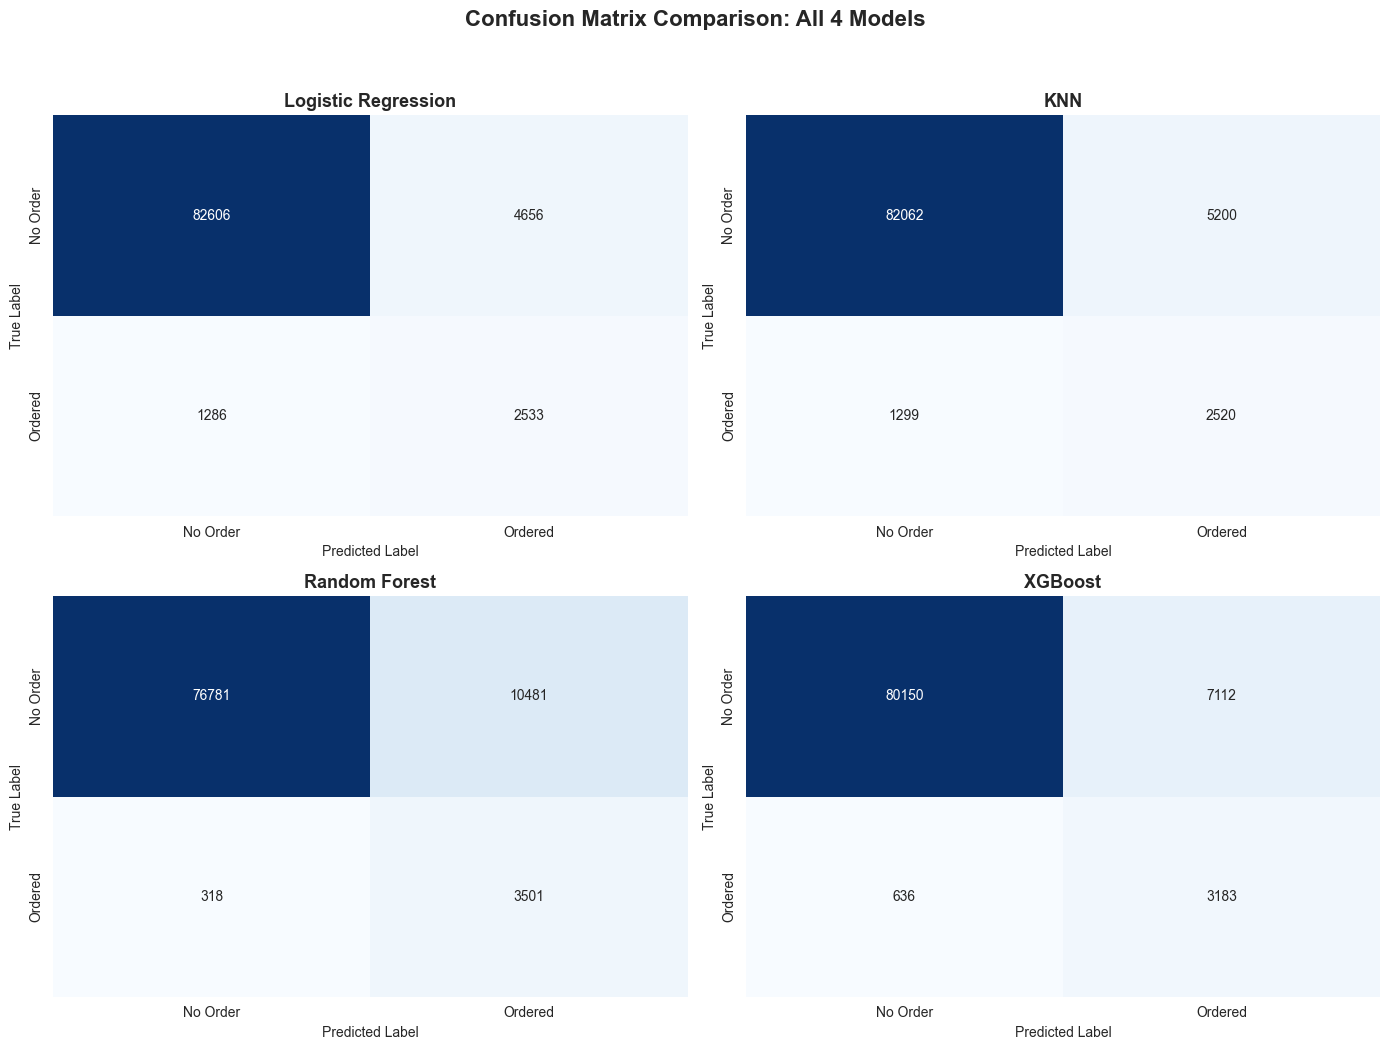

In [27]:
# --- confusion matrix comparison for all 4 models ---

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
plt.suptitle('Confusion Matrix Comparison: All 4 Models', fontsize=16, fontweight='bold')

# Loop through our dictionary keys
for i, name in enumerate(results.keys()):
    ax = axes[i//2, i%2]
    
    # Grab cached predictions
    y_pred = results[name]['y_pred']
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f"{name}", fontweight='bold', fontsize=13)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_xticklabels(['No Order', 'Ordered'])
    ax.set_yticklabels(['No Order', 'Ordered'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

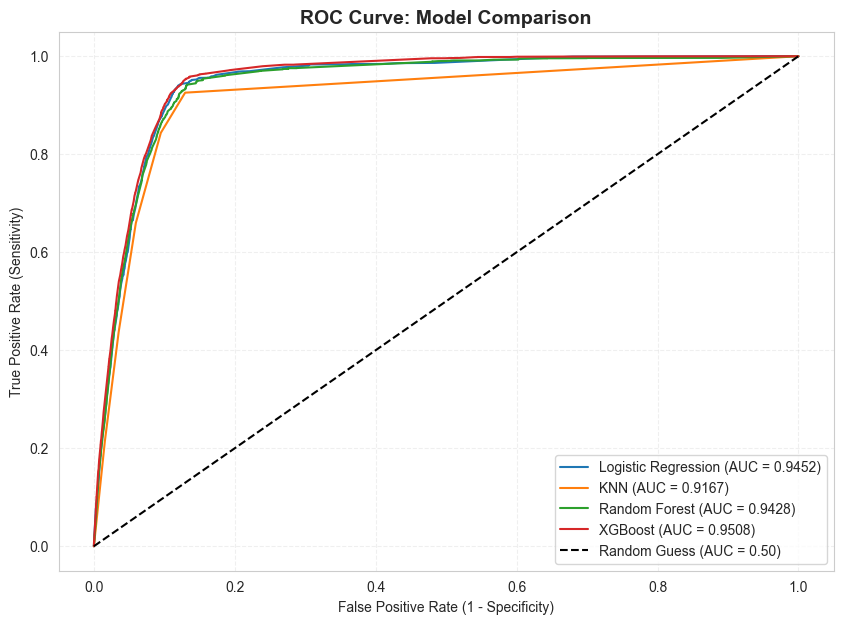

In [28]:
plt.figure(figsize=(10, 7))

for name, metrics in results.items():
    y_prob = metrics['y_prob']
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve: Model Comparison', fontweight='bold', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3, linestyle='--')
plt.show()

## Results - Model Comparison

--- Final Model Performance Prediction Table ---


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.934761,0.352344,0.663263,0.460211,0.945234
XGBoost,0.914933,0.309179,0.833464,0.451042,0.950765
KNN,0.928646,0.326425,0.659859,0.436780,0.916707
Random Forest,0.881435,0.250393,0.916732,0.393349,0.942773


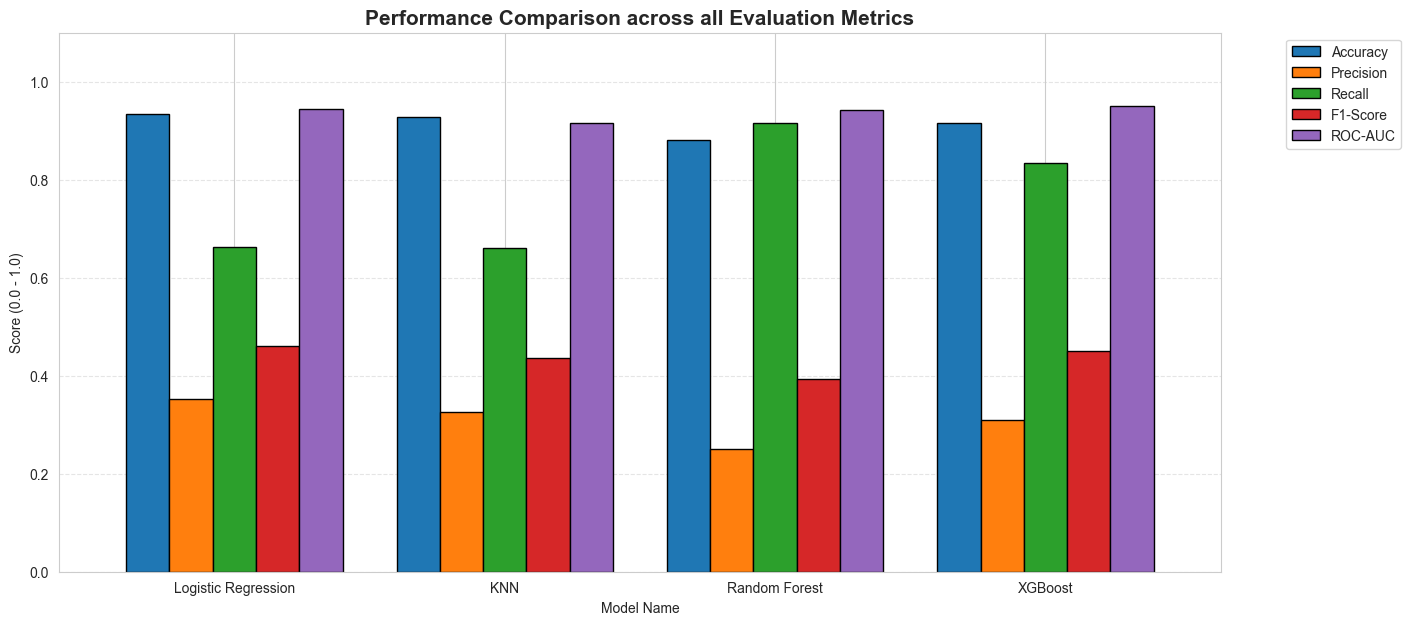

In [29]:
# 1. Generate the Comparison Table
# We filter out the arrays (y_pred, y_prob) to keep the table clean
table_data = {name: {k: v for k, v in m.items() if k not in ['y_pred', 'y_prob']} 
             for name, m in results.items()}
perf_df = pd.DataFrame(table_data).T

print("--- Final Model Performance Prediction Table ---")
display(perf_df.sort_values(by='F1-Score', ascending=False))

# 2. Performance Comparison Bar Chart
perf_df.plot(kind='bar', figsize=(15, 7), width=0.8, edgecolor='black')
plt.title('Performance Comparison across all Evaluation Metrics', fontweight='bold', fontsize=15)
plt.ylabel('Score (0.0 - 1.0)')
plt.xlabel('Model Name')
plt.xticks(rotation=0)
plt.ylim(0, 1.1) # Give space for the legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

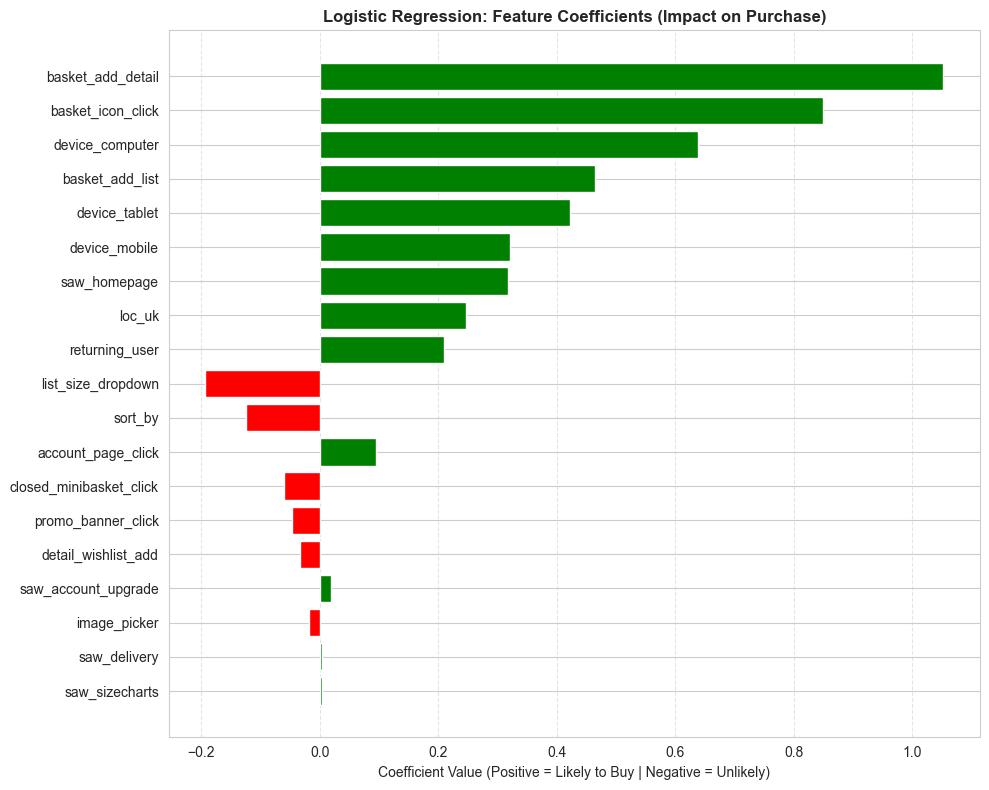

In [30]:
# --- Feature Importance for best performed model- Logistic Regression ---

# 1. Get the names and the coefficients
# We use .coef_[0] because Logistic Regression returns a 2D array
feature_names = X_train_clean.columns
coefficients = log_reg_clean.coef_[0]

# 2. Create a DataFrame for easy sorting
feat_importances = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
feat_importances['Abs_Weight'] = feat_importances['Coefficient'].abs()
feat_importances = feat_importances.sort_values(by='Abs_Weight', ascending=True)

# 3. Plotting
plt.figure(figsize=(10, 8))
colors = ['red' if x < 0 else 'green' for x in feat_importances['Coefficient']]
plt.barh(feat_importances['Feature'], feat_importances['Coefficient'], color=colors)

plt.title('Logistic Regression: Feature Coefficients (Impact on Purchase)', fontweight='bold')
plt.xlabel('Coefficient Value (Positive = Likely to Buy | Negative = Unlikely)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()